In [8]:
# Install dependency if needed:
# !pip -q install "kagglehub[pandas-datasets]"

import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "data.csv"

# Load the latest version
# Requires Kaggle access to download public datasets.
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "uciml/breast-cancer-wisconsin-data",
    file_path,
)

print("Data shape:", df.shape)
df.head()

/tmp/ipykernel_498277/3698310770.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Data shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [9]:
def prepare_data(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    data = df.copy()
    if "Unnamed: 32" in data.columns:
        data = data.drop(columns=["Unnamed: 32"])
    if "id" in data.columns:
        data = data.drop(columns=["id"])

    y = data["diagnosis"].map({"M": 1, "B": -1}).to_numpy()
    X = data.drop(columns=["diagnosis"]).to_numpy(dtype=float)
    return X, y


def train_test_split(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = 0.2,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    split = int(len(X) * (1 - test_size))
    train_idx = idx[:split]
    test_idx = idx[split:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


def standardize_fit_transform(
    X_train: np.ndarray,
    X_test: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1.0
    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std, mean, std


X, y = prepare_data(df)
X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train, X_test, mean, std = standardize_fit_transform(X_train, X_test)

print("Train samples:", X_train.shape[0], "Test samples:", X_test.shape[0])
print("Feature count:", X_train.shape[1])

Train samples: 455 Test samples: 114
Feature count: 30


In [10]:
from scipy.optimize import Bounds, LinearConstraint, minimize


def train_soft_margin_svm(
    X: np.ndarray,
    y: np.ndarray,
    C: float = 1.0,
    maxiter: int = 500,
) -> tuple[np.ndarray, float, np.ndarray, object]:
    n, d = X.shape

    def objective(z: np.ndarray) -> float:
        w = z[:d]
        xi = z[d + 1 :]
        return 0.5 * np.dot(w, w) + C * np.sum(xi)

    def grad(z: np.ndarray) -> np.ndarray:
        w = z[:d]
        g = np.zeros_like(z)
        g[:d] = w
        g[d + 1 :] = C
        return g

    A = np.hstack([X * y[:, None], y[:, None], np.eye(n)])
    linear_constraint = LinearConstraint(A, np.ones(n), np.full(n, np.inf))
    bounds = Bounds(
        np.concatenate([np.full(d + 1, -np.inf), np.zeros(n)]),
        np.full(d + 1 + n, np.inf),
    )

    z0 = np.zeros(d + 1 + n)
    result = minimize(
        objective,
        z0,
        jac=grad,
        method="trust-constr",
        constraints=[linear_constraint],
        bounds=bounds,
        options={"maxiter": maxiter, "verbose": 0},
    )

    w = result.x[:d]
    b = float(result.x[d])
    xi = result.x[d + 1 :]
    return w, b, xi, result


def support_vector_indices(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    b: float,
    tol: float = 1e-3,
) -> np.ndarray:
    margins = y * (X @ w + b)
    return np.where(margins <= 1 + tol)[0]


def bias_from_support_vectors(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    support_idx: np.ndarray,
) -> float:
    if support_idx.size == 0:
        return 0.0
    return float(np.mean(y[support_idx] - X[support_idx] @ w))


def predict(X: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    scores = X @ w + b
    return np.where(scores >= 0, 1, -1)


def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(y_true == y_pred))


C = 1.0
w, b, xi, result = train_soft_margin_svm(X_train, y_train, C=C)
sv_idx = support_vector_indices(X_train, y_train, w, b)

# Recompute bias using support vectors to align with the margin definition.
b = bias_from_support_vectors(X_train, y_train, w, sv_idx)

train_acc = accuracy(y_train, predict(X_train, w, b))
test_acc = accuracy(y_test, predict(X_test, w, b))

print("Optimization success:", result.success)
print("Support vectors:", len(sv_idx))
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")

Optimization success: True
Support vectors: 39
Train accuracy: 0.9890
Test accuracy:  0.9912


## Visualization (PCA view)
A quick 2D PCA projection helps visualize class separation and support vectors. This is only a diagnostic view; the SVM is trained in the full feature space.

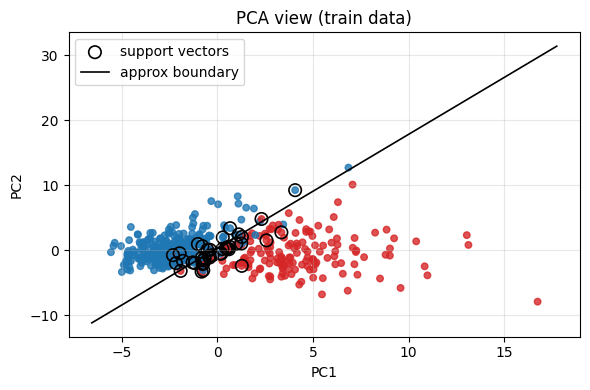

In [12]:
import matplotlib.pyplot as plt


def pca_2d(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    Xc = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    Z = Xc @ Vt[:2].T
    return Z, Vt[:2]


def plot_pca_view(
    Z: np.ndarray,
    y: np.ndarray,
    sv_idx: np.ndarray,
    w_proj: np.ndarray,
    b: float,
) -> None:
    plt.figure(figsize=(6, 4))
    colors = np.where(y == 1, "tab:red", "tab:blue")
    plt.scatter(Z[:, 0], Z[:, 1], c=colors, s=22, alpha=0.8)

    if sv_idx.size > 0:
        plt.scatter(
            Z[sv_idx, 0],
            Z[sv_idx, 1],
            facecolors="none",
            edgecolors="black",
            s=80,
            linewidths=1.2,
            label="support vectors",
        )

    xs = np.linspace(Z[:, 0].min() - 1, Z[:, 0].max() + 1, 200)
    if abs(w_proj[1]) > 1e-12:
        ys = -(w_proj[0] * xs + b) / w_proj[1]
        plt.plot(xs, ys, color="black", linewidth=1.2, label="approx boundary")

    plt.title("PCA view (train data)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(loc="best")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Z_train, V2 = pca_2d(X_train)
w_proj = V2 @ w
plot_pca_view(Z_train, y_train, sv_idx, w_proj, b)

In [14]:
print(
    "Diagnostic: soft-margin SVM (primal, linear) | "
    f"C={C} | solver=trust-constr | "
    f"support_vectors={len(sv_idx)} | "
    f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f}"
)

Diagnostic: soft-margin SVM (primal, linear) | C=1.0 | solver=trust-constr | support_vectors=39 | train_acc=0.9890 | test_acc=0.9912
